Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Generate Synthetic Dataset

In [2]:
np.random.seed(42)

In [3]:
n = 10000

In [4]:
data = {
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
}

In [5]:
df = pd.DataFrame(data)

In [6]:
df.to_csv("healthcare_dataset.csv", index=False)

In [7]:
print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
0           1   58  Female             164          175          234   
1           2   71  Female             176           70          244   
2           3   48  Female             103          115          207   
3           4   34    Male             123          157          201   
4           5   62  Female             177           91          210   

   Heart_Rate  
0          77  
1          93  
2          77  
3          99  
4          90  


Basic Info

In [8]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB
None


In [9]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
        Patient_ID           Age  Blood_Pressure   Sugar_Level   Cholesterol  \
count  10000.00000  10000.000000    10000.000000  10000.000000  10000.000000   
mean    5000.50000     50.290400      129.668100    135.618200    224.568500   
std     2886.89568     17.588957       29.138093     37.843946     43.604943   
min        1.00000     20.000000       80.000000     70.000000    150.000000   
25%     2500.75000     35.000000      104.000000    103.000000    187.000000   
50%     5000.50000     50.000000      130.000000    136.000000    224.000000   
75%     7500.25000     66.000000      155.000000    169.000000    262.000000   
max    10000.00000     80.000000      180.000000    200.000000    300.000000   

         Heart_Rate  
count  10000.000000  
mean      89.890900  
std       17.483803  
min       60.000000  
25%       75.000000  
50%       90.000000  
75%      105.000000  
max      120.000000  


Risk Classification Function

In [10]:
def classify_risk(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 160 or
        row["Cholesterol"] > 240 or
        row["Heart_Rate"] > 100):
        return "High"
    elif (row["Blood_Pressure"] > 120 or
          row["Sugar_Level"] > 140):
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df.apply(classify_risk, axis=1)

df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,1,58,Female,164,175,234,77,High
1,2,71,Female,176,70,244,93,High
2,3,48,Female,103,115,207,77,Low
3,4,34,Male,123,157,201,99,Medium
4,5,62,Female,177,91,210,90,High


Group Analysis

In [11]:
print("\nAge vs Blood Pressure:\n", df.groupby("Age")["Blood_Pressure"].mean())


Age vs Blood Pressure:
 Age
20    126.673203
21    134.118750
22    131.197452
23    130.812865
24    130.966216
         ...    
76    129.455090
77    129.023529
78    132.104396
79    130.748538
80    133.987879
Name: Blood_Pressure, Length: 61, dtype: float64


In [12]:
print("\nGender-wise Analysis:\n", df.groupby("Gender")[["Blood_Pressure","Sugar_Level","Cholesterol"]].mean())


Gender-wise Analysis:
         Blood_Pressure  Sugar_Level  Cholesterol
Gender                                          
Female      129.397387   136.374271   224.673568
Male        129.936119   134.869652   224.464478


Visualization

Histogram

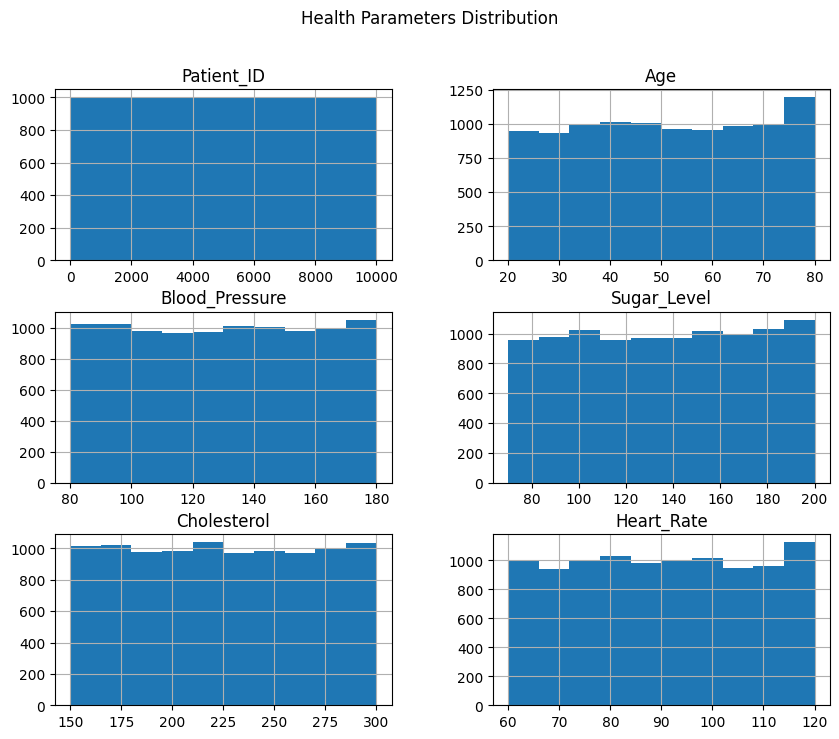

In [13]:
df.hist(figsize=(10,8))
plt.suptitle("Health Parameters Distribution")
plt.show()

Count Plot(Risk Level)

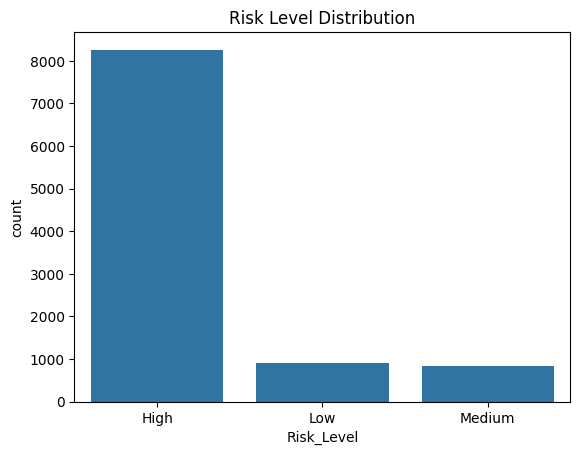

In [14]:
sns.countplot(x="Risk_Level", data=df)
plt.title("Risk Level Distribution")
plt.show()

Scatter Plot

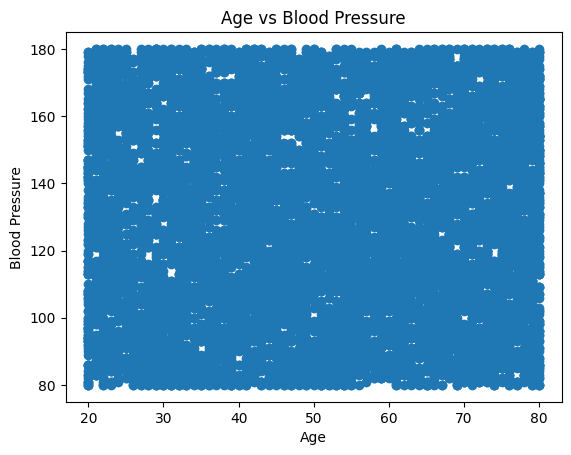

In [15]:
plt.scatter(df["Age"], df["Blood_Pressure"])
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Age vs Blood Pressure")
plt.show()

Box Plot

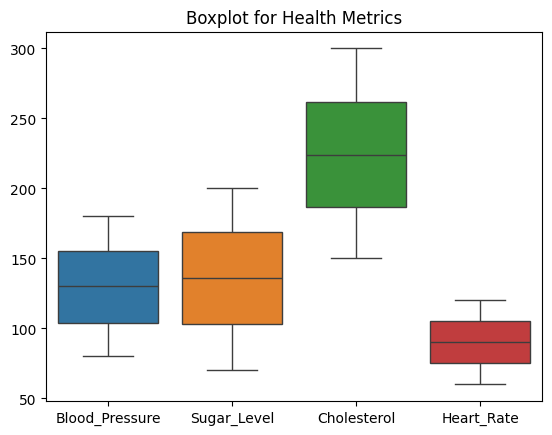

In [16]:
sns.boxplot(data=df[["Blood_Pressure", "Sugar_Level", "Cholesterol", "Heart_Rate"]])
plt.title("Boxplot for Health Metrics")
plt.show()

Heatmap

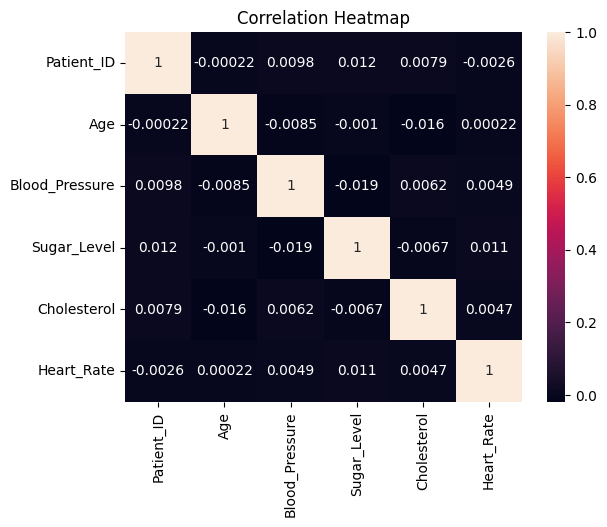

In [17]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()